# MODELIZACIÓN CLASIFICACIÓN PROBABILITY OF DEFAULT

## IMPORTAR PAQUETES

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
from pathlib import Path
import openpyxl
import sqlalchemy as sa

# Desactivar notación científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)

# Cargar variables de entorno
load_dotenv()

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## IMPORTAR LOS DATOS

In [21]:
df = pd.read_pickle('../02_datos/03_Entrenamiento/df_tablon_pd.pkl')

In [22]:
x = df.drop(columns='target_pd')
y = df.target_pd

## MODELIZAR

### Reservar el dataset de validacion

In [23]:
from sklearn.model_selection import train_test_split
train_x,val_x,train_y,val_y = train_test_split(x,y,test_size=0.3)

### Crear el pipe y el diccionario de algorimos, parámetros y valores a testar

Modificar para dejar solo los algoritmos que se quieran testar.

Modificar los parámetros.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe = Pipeline([('algoritmo',LogisticRegression())])

grid = [{'algoritmo': [LogisticRegression(solver = 'saga')],
         'algoritmo__l1_ratio': [0, 0.5, 1],
         'algoritmo__C': [0.01,0.25,0.5,0.75,1]}
       ]

### Optimizar los hiper parámetros

Elegir si se quiere usar grid search o random search.

Comentar la opción que no se vaya a usar.

####  Con grid search

In [25]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator= pipe, 
                           param_grid = grid, 
                           cv = 5, 
                           scoring = 'roc_auc',
                           verbose = 0,
                           n_jobs = -1)

modelo = grid_search.fit(train_x,train_y)

In [26]:
salida = pd.DataFrame(grid_search.cv_results_).sort_values(by = 'rank_test_score').reset_index(drop=True).head(5)
salida

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algoritmo,param_algoritmo__C,param_algoritmo__l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,4.161,0.214,0.006,0.001,LogisticRegression(solver='saga'),1.000,0.500,{'algoritmo': LogisticRegression(solver='saga'...,0.710,0.701,0.705,0.698,0.699,0.703,0.004,1
1,4.780,0.142,0.007,0.001,LogisticRegression(solver='saga'),1.000,0.000,{'algoritmo': LogisticRegression(solver='saga'...,0.710,0.701,0.705,0.698,0.699,0.703,0.004,2
2,2.001,0.216,0.011,0.001,LogisticRegression(solver='saga'),1.000,1.000,{'algoritmo': LogisticRegression(solver='saga'...,0.710,0.702,0.705,0.698,0.698,0.703,0.004,3
3,4.549,0.159,0.012,0.001,LogisticRegression(solver='saga'),0.750,0.500,{'algoritmo': LogisticRegression(solver='saga'...,0.710,0.701,0.705,0.698,0.699,0.703,0.004,4
4,5.003,0.116,0.011,0.002,LogisticRegression(solver='saga'),0.750,0.000,{'algoritmo': LogisticRegression(solver='saga'...,0.710,0.701,0.705,0.698,0.699,0.703,0.004,5


Vemos que el resultados del auc es el mismo en todas las primeras configuraciones.

Y reentreamos el modelo con esa configuración.

In [27]:
#Instanciar
rl = LogisticRegression(solver = 'saga', C = 1, l1_ratio = 1)
#Entrenar
rl.fit(train_x,train_y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

Podemos revisar los coefecientes para ver los que son cero y las variables más importantes.

In [28]:
coeficientes = pd.DataFrame(data = rl.coef_, columns = rl.feature_names_in_).stack().droplevel(level = 0).sort_values()
coeficientes

tipo_interes_mms                       -2.229
ingresos_mms                           -1.413
principal_mms                          -1.124
dti_mms                                -0.647
ingresos_verificados_Not Verified      -0.275
finalidad_house                        -0.225
num_cuotas_ 36 months                  -0.181
finalidad_vacation                     -0.143
finalidad_other                        -0.142
vivienda_MORTGAGE                      -0.119
finalidad_car                          -0.108
antigüedad_empleo_oe_mms               -0.076
finalidad_credit_card                  -0.048
finalidad_moving                        0.000
vivienda_OWN                            0.000
ingresos_verificados_Source Verified    0.000
finalidad_home_improvement              0.000
num_cuotas_ 60 months                   0.009
finalidad_debt_consolidation            0.023
finalidad_medical                       0.030
finalidad_major_purchase                0.062
ingresos_verificados_Verified     

## EVALUAR

### Predecir sobre validación

In [29]:
pred = rl.predict_proba(val_x)[:, 1]

### Evaluar sobre validación

In [30]:
from sklearn.metrics import roc_auc_score
roc_auc_score(val_y, pred)

0.6985954071400636

## REPORTING DEL MODELO

### Gain Chart

In [31]:
def gain_chart(y_true, y_pred, figsize=(8, 6)):
    df_gain = pd.DataFrame({'y': y_true, 'pred': y_pred})
    df_gain = df_gain.sort_values('pred', ascending=False).reset_index(drop=True)

    df_gain['acumulado'] = df_gain['y'].cumsum() / df_gain['y'].sum()
    df_gain['porcentaje_muestra'] = (np.arange(len(df_gain)) + 1) / len(df_gain)

    plt.figure(figsize=figsize)
    plt.plot(df_gain['porcentaje_muestra'], df_gain['acumulado'], label='Modelo')
    plt.plot(df_gain['porcentaje_muestra'], df_gain['porcentaje_muestra'], '--', label='Aleatorio')
    plt.xlabel('Porcentaje de muestra')
    plt.ylabel('Porcentaje acumulado de positivos')
    plt.title('Gain Chart')
    plt.legend()
    plt.grid()
    plt.show()

    return df_gain



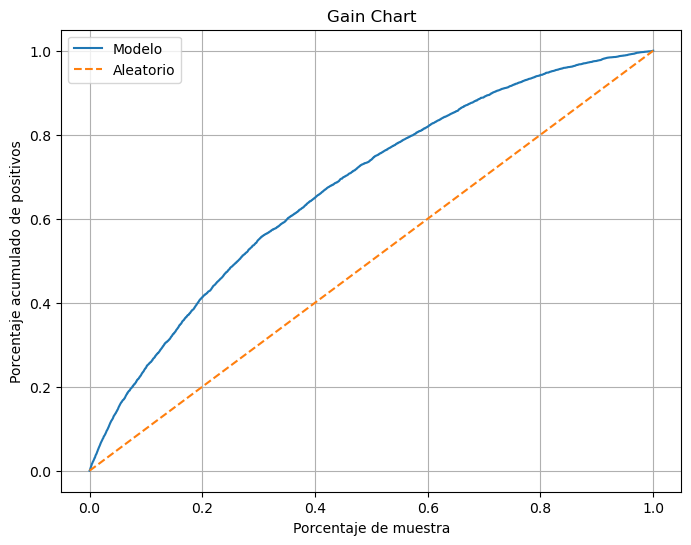

,y,pred,acumulado,porcentaje_muestra
0,0,0.735,0.000,0.000
1,1,0.701,0.000,0.000
2,0,0.683,0.000,0.000
3,1,0.666,0.000,0.000
4,0,0.666,0.000,0.000
...,...,...,...,...
41878,0,0.015,1.000,1.000
41879,0,0.015,1.000,1.000
41880,0,0.014,1.000,1.000
41881,0,0.014,1.000,1.000


In [32]:
gain_chart(val_y, pred)

### Lift Chart

In [33]:
def lift_chart(y_true, y_pred):
    df = pd.DataFrame({'y': y_true, 'pred': y_pred})
    df = df.sort_values('pred', ascending=False).reset_index(drop=True)
    total_positivos = df['y'].sum()
    total_muestra = len(df)
    porcentaje_muestra = np.arange(1, total_muestra + 1) / total_muestra
    acumulado_positivos = df['y'].cumsum()
    lift_acumulado = (acumulado_positivos / porcentaje_muestra) / total_positivos

    plt.figure(figsize=(8,6))
    plt.plot(porcentaje_muestra, lift_acumulado, label='Modelo', color='green')
    plt.axhline(1, color='black', linestyle='--', label='Aleatorio')
    plt.xlabel('Porcentaje de muestra')
    plt.ylabel('Lift acumulado')
    plt.title('Lift Curve')
    plt.legend()
    plt.grid()
    plt.show()

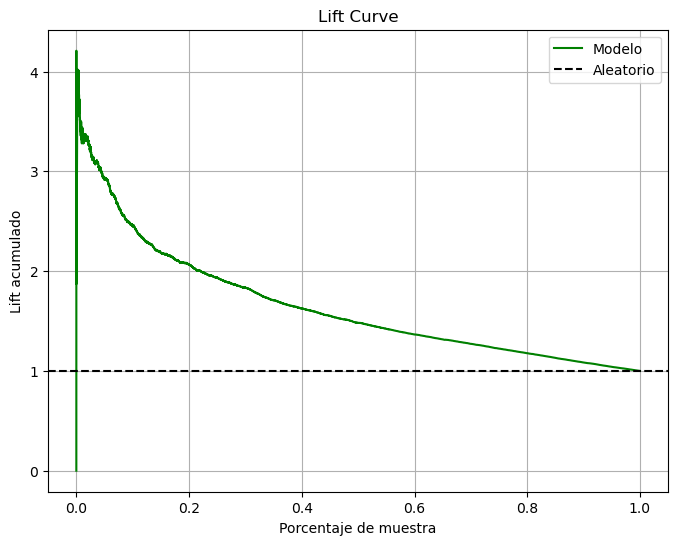

In [34]:
lift_chart(val_y, pred)

### ROC Chart

In [35]:
def roc_curve(y_true, y_pred, n_thresholds=100):
    df = pd.DataFrame({'y': y_true, 'pred': y_pred})
    thresholds = np.linspace(0, 1, n_thresholds)
    tpr = []
    fpr = []
    total_pos = (df['y'] == 1).sum()
    total_neg = (df['y'] == 0).sum()
    for thresh in thresholds:
        y_pred_bin = (df['pred'] >= thresh).astype(int)
        tp = ((df['y'] == 1) & (y_pred_bin == 1)).sum()
        fp = ((df['y'] == 0) & (y_pred_bin == 1)).sum()
        tpr.append(tp / total_pos if total_pos > 0 else 0)
        fpr.append(fp / total_neg if total_neg > 0 else 0)
    tpr = np.array(tpr)
    fpr = np.array(fpr)

    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='green', label='Modelo')
    plt.plot([0,1], [0,1], '--', color='black', label='Aleatorio')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid()
    plt.show()

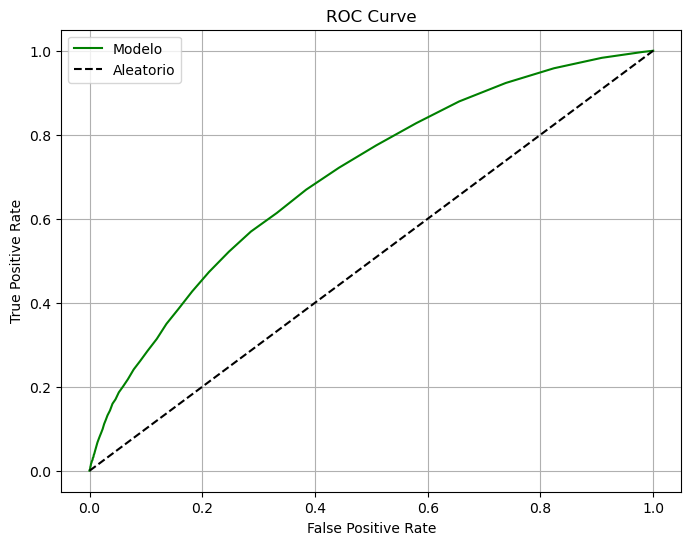

In [36]:
roc_curve(val_y, pred)